> **3.1 Task 1: Bijection Learning**
> 
> Each sequence is derived from a new random bijection $\pi : \{1, \dots, V\} \to \{1, \dots, V\}$ with $V = 20$. At position $k$, the model has observed $k - 1$ distinct input–output pairs and must predict $\pi(x_k)$. Because inputs never repeat, the Bayes-optimal posterior over $\pi(x_k)$ is uniform over the $V - k + 1$ unseen values.
> 
> **Bayesian ground truth.** Let $O_{k-1}$ be observed outputs. Then
> 
> $$p(\pi(x_k) = y \mid \text{context}) = \begin{cases} \frac{1}{V-k+1}, & y \notin O_{k-1}, \\ 0, & y \in O_{k-1}, \end{cases}$$
> 
> with entropy $H_{\text{Bayes}}(k) = \log_2(V - k + 1)$.
> 
> **Evaluation.** We compute MAE over a held-out set of 2,000 bijections. Because $20! \approx 2.4 \times 10^{18}$ possible bijections exist and training uses only $10^5$ samples, no bijection is seen twice; the task enforces true hypothesis elimination.
> 
> **Sequence format.** Each training example is tokenized as
> 
> $$[x_1, y_1, \text{SEP}, x_2, y_2, \text{SEP}, \dots, x_{19}, \text{SEP}],$$
> 
> with teacher forcing at every $y_k$ position.


Let's build the dataset.

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from tqdm.autonotebook import tqdm

# --- 1. DATASET ---
class BijectionTask1(Dataset):
    def __init__(self, mappings, V=20):
        """
        mappings: A pre-generated tensor of shape (num_samples, V)
                  containing the specific bijections for this dataset.
        """
        self.mappings = mappings
        self.num_samples = mappings.shape[0]
        self.V = V
        self.staircase_entropy = torch.tensor([np.log2(V - k) for k in range(V - 1)], dtype=torch.float)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # 1. Fetch the exact 'Secret Rule' assigned to this sample
        # We put it in a 1-indexed tensor so we can look up y = mapping[x] easily
        mapping = torch.empty(self.V + 1, dtype=torch.long)
        mapping[1:] = self.mappings[idx]
        
        # 2. Randomize the presentation order of x
        x_order = torch.randperm(self.V)[:self.V - 1] + 1
        y_order = mapping[x_order]
        
        # 3. Interleave [x, y, SEP]
        seq = torch.zeros((self.V - 1) * 3, dtype=torch.long)
        seq[0::3] = x_order
        seq[1::3] = y_order
        # seq[2::3] is already 0 (SEP token)
        
        return {
            "input_ids": seq[:-1],
            "labels": seq[1:],
            "staircase": self.staircase_entropy
        }

# --- Utility to Generate Unseen Splits ---
def generate_disjoint_bijections(num_train, num_test, V=20):
    """
    Generates permutations for Train and Test simultaneously to guarantee
    we can track exactly what the model is learning.
    """
    total_needed = num_train + num_test
    # A fast way to generate millions of unique random permutations in PyTorch
    rand_vals = torch.rand(total_needed, V)
    all_mappings = torch.argsort(rand_vals, dim=1) + 1
    
    train_mappings = all_mappings[:num_train]
    test_mappings = all_mappings[num_train:]
    return train_mappings, test_mappings

# --- Verification ---
# Generate a tiny dummy split for verification
dummy_train, dummy_test = generate_disjoint_bijections(num_train=10, num_test=2, V=20)
task1_data = BijectionTask1(mappings=dummy_train, V=20)
first_sample = task1_data[0]

print("Sequence structure:", first_sample['input_ids'].tolist())
print("Staircase Entropy (bits per step):", [round(e, 3) for e in first_sample['staircase'].tolist()])

# --- Dataset Shape Analysis ---
print(f"Number of samples in train dataset: {len(task1_data)}")
print(f"Length of a single sequence (L): {first_sample['input_ids'].shape[0]} tokens")
print(f"Number of prediction steps (k): {first_sample['staircase'].shape[0]} steps")

Sequence structure: [2, 14, 0, 13, 18, 0, 14, 8, 0, 3, 5, 0, 15, 4, 0, 1, 13, 0, 18, 1, 0, 20, 19, 0, 10, 12, 0, 5, 2, 0, 12, 9, 0, 4, 6, 0, 19, 10, 0, 9, 17, 0, 11, 7, 0, 7, 15, 0, 6, 3, 0, 8, 20, 0, 17, 11]
Staircase Entropy (bits per step): [4.322, 4.248, 4.17, 4.087, 4.0, 3.907, 3.807, 3.7, 3.585, 3.459, 3.322, 3.17, 3.0, 2.807, 2.585, 2.322, 2.0, 1.585, 1.0]
Number of samples in train dataset: 10
Length of a single sequence (L): 56 tokens
Number of prediction steps (k): 19 steps


### Dataset Dimensions & Metadata

1.  **`input_ids` shape: `[56]`**
    *   **Why 56?** We have 19 pairs. Each pair is 3 tokens (`x`, `y`, `SEP`). $19 \times 3 = 57$. We remove the last token (`SEP`) because there is nothing to predict after it. So, $57 - 1 = 56$.
2.  **`labels` shape: `[56]`**
    *   This is the same length as `input_ids`. It is shifted right by 1, so the model learns to predict the "next" token at every position.
3.  **`staircase` shape: `[19]`**
    *   This contains the 19 levels of uncertainty. 
    *   **Mapping:** The model's entropy at `input_ids` indices **0, 3, 6, 9...** (the positions of $x_1, x_2, x_3...$) should match these 19 values.

---

### 1. The Architecture (from Page 8, Section 3.5)

> **Bijection transformer (2.67M):** 6 layers, 6 heads, $d_{model} = 192$, $d_{ffn} = 768$.
> 
> Both use learned token embeddings, learned absolute positional embeddings, pre-norm residual blocks, and standard multi-head self-attention.

### 2. The Training Protocol (from Page 9, Section 3.6)

> **Optimization.** AdamW with $\beta_1 = 0.9, \beta_2 = 0.999$, weight decay 0.01, gradient clipping at 1.0. Batch size is 64 for all tasks.
> 
> **Learning rates and training steps.**
> * **Bijections:** constant $10^{-3}$ for 150k steps.
> 
> **Data sampling.** Every batch draws fresh bijections or fresh HMMs; sequences never repeat.
> 
> **Teacher forcing.** Cross-entropy loss is applied at each supervised prediction position.

In [10]:
# --- HYPERPARAMETERS (Section 3.5 & 3.6) ---
V = 20
VOCAB_SIZE = 21   # 1-20 + SEP token (0)
D_MODEL = 192
NHEAD = 6
NUM_LAYERS = 6
D_FFN = 768
MAX_SEQ_LEN = 56  # (19 pairs * 3 tokens) - 1

BATCH_SIZE = 64
LR = 2e-3         # OG: 1e-3
STEPS = 3000      # OG: 150k 
MONITOR_INTERVAL = 100

TEST_SAMPLES = 2000 # As per paper for the evaluation

WEIGHT_DECAY = 0.01
CLIP = 1.0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- 2. MODEL DEFINITION ---
class BijectionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(VOCAB_SIZE, D_MODEL)
        self.pos_embedding = nn.Parameter(torch.zeros(1, MAX_SEQ_LEN, D_MODEL))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, nhead=NHEAD, dim_feedforward=D_FFN,
            dropout=0.0, activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=NUM_LAYERS, enable_nested_tensor=False
        )
        self.ln_f = nn.LayerNorm(D_MODEL)
        self.head = nn.Linear(D_MODEL, VOCAB_SIZE, bias=False)

    def forward(self, x):
        b, t = x.size()
        x = self.token_embedding(x) + self.pos_embedding[:, :t, :]
        mask = torch.triu(torch.ones(t, t, device=x.device) * float('-inf'), diagonal=1)
        x = self.transformer(x, mask=mask, is_causal=True)
        return self.head(self.ln_f(x))

# --- 3. EXPERIMENTAL SETUP (Strict Split) ---
print(f"Pre-generating disjoint Train ({STEPS * BATCH_SIZE}) and Test ({TEST_SAMPLES}) splits...")
train_mappings, test_mappings = generate_disjoint_bijections(num_train=STEPS * BATCH_SIZE, num_test=TEST_SAMPLES, V=V)

train_dataset = BijectionTask1(mappings=train_mappings, V=V)
# We will use this test_dataset in Cell 3 later!
test_dataset = BijectionTask1(mappings=test_mappings, V=V) 

loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)

model = BijectionTransformer().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999), fused=torch.cuda.is_available())

def get_predictive_entropy(logits):
    probs = F.softmax(logits, dim=-1)
    log_probs = F.log_softmax(logits, dim=-1)
    return -(probs * log_probs).sum(dim=-1) / np.log(2)

Y_POSITIONS = torch.arange(0, MAX_SEQ_LEN, 3, device=DEVICE)

# --- 4. TRAINING LOOP ---
print(f"Starting training on {DEVICE}...")
model.train()

pbar = tqdm(loader, total=STEPS, desc="Training")
for step, batch in enumerate(pbar):
    if step >= STEPS: break
    
    inputs = batch['input_ids'].to(DEVICE, non_blocking=True)
    targets = batch['labels'].to(DEVICE, non_blocking=True)
    
    logits = model(inputs)
    
    loss = F.cross_entropy(logits[:, Y_POSITIONS, :].reshape(-1, VOCAB_SIZE), targets[:, Y_POSITIONS].reshape(-1))
    
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
    optimizer.step()

    # --- MONITORING ---
    if step % MONITOR_INTERVAL == 0:
        with torch.no_grad():
            ideal_staircase = batch['staircase'].to(DEVICE, non_blocking=True)[0]
            model_entropy = get_predictive_entropy(logits[0, Y_POSITIONS, :])
            mae = torch.abs(model_entropy - ideal_staircase).mean().item()
            pbar.set_postfix({"Loss": f"{loss.item():.4f}", "MAE (bits)": f"{mae:.4f}"})

print("Training Complete.")

Pre-generating disjoint Train (192000) and Test (2000) splits...
Starting training on cuda...


Training: 100%|██████████| 3000/3000 [03:06<00:00, 16.09it/s, Loss=2.2533, MAE (bits)=0.0339]

Training Complete.


Evaluating on 2000 strictly unseen bijections...
Final Test MAE: 0.0367 bits
Plot successfully saved to: results\bijection_task1_staircase.pdf


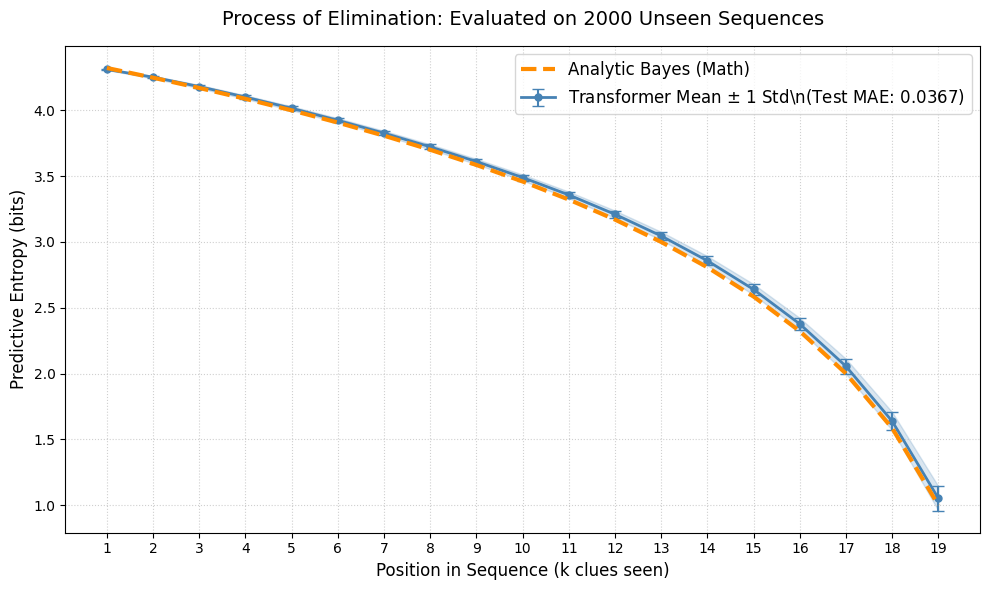

In [15]:
import os
import matplotlib.pyplot as plt

# --- 1. EVALUATION (Full Test Set) ---
print(f"Evaluating on {len(test_dataset)} strictly unseen bijections...")

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=0)

model.eval()
total_mae = 0.0
all_predictions = [] 

with torch.no_grad():
    for batch in test_loader:
        inputs = batch['input_ids'].to(DEVICE)
        ideal_staircase = batch['staircase'].to(DEVICE)
        
        logits = model(inputs)
        model_entropy = get_predictive_entropy(logits[:, Y_POSITIONS, :])
        
        batch_mae = torch.abs(model_entropy - ideal_staircase).mean().item()
        total_mae += batch_mae * inputs.size(0) 
        
        all_predictions.append(model_entropy.cpu())

all_predictions_tensor = torch.cat(all_predictions, dim=0)

mean_entropy = all_predictions_tensor.mean(dim=0).numpy()
std_entropy = all_predictions_tensor.std(dim=0).numpy()

final_mae = total_mae / len(test_dataset)
print(f"Final Test MAE: {final_mae:.4f} bits")

# --- 2. PLOT THE STATISTICAL STAIRCASE ---
ideal_staircase_np = test_dataset[0]['staircase'].numpy()
k_steps = np.arange(1, len(ideal_staircase_np) + 1)

plt.figure(figsize=(10, 6))

plt.plot(k_steps, ideal_staircase_np, 
         label="Analytic Bayes (Math)", 
         color='darkorange', linestyle='--', linewidth=3, zorder=3)

plt.errorbar(k_steps, mean_entropy, yerr=std_entropy, 
             label=fr"Transformer Mean $\pm$ 1 Std\n(Test MAE: {final_mae:.4f})", 
             color='steelblue', marker='o', linewidth=2, markersize=5, 
             capsize=4, elinewidth=1.5, zorder=2)

plt.fill_between(k_steps, mean_entropy - std_entropy, mean_entropy + std_entropy, 
                 color='steelblue', alpha=0.2, zorder=1)

plt.title(f"Process of Elimination: Evaluated on {len(test_dataset)} Unseen Sequences", fontsize=14, pad=15)
plt.xlabel("Position in Sequence (k clues seen)", fontsize=12)
plt.ylabel("Predictive Entropy (bits)", fontsize=12)
plt.xticks(k_steps)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()

# --- 3. SAVE THE PLOT ---
# Create the results directory if it doesn't exist
output_dir = "results"
os.makedirs(output_dir, exist_ok=True)

# Save as PDF
file_path = os.path.join(output_dir, "bijection_task1_staircase.pdf")
plt.savefig(file_path, format='pdf', bbox_inches='tight')
print(f"Plot successfully saved to: {file_path}")

# Display the plot in the notebook
plt.show()

### From Page 10 (Section 4.1: Bijection Wind Tunnel)

> **Inside-model consistency.** Layer-wise ablations (Figure 5) show that removing any block increases error by more than an order of magnitude, confirming a deeply compositional computation. Head-wise ablations (Figure 6) identify a single Layer 0 hypothesis-frame head whose removal is uniquely destructive, consistent with the geometric analysis in Section 5.

### From Page 19 (Section 5.2: Sequential Bayesian Elimination Across Depth)

> **Hierarchical compositionality.** Layer-wise ablations (Figure 5) show that removing any single layer (attention + FFN, as implemented) increases calibration error by more than an order of magnitude. This demonstrates that the computation is not shallow or redundant. Each layer provides a distinct and non-interchangeable refinement step, forming a sequential, compositional realization of Bayesian updates. Together, these observations indicate that transformers implement Bayesian elimination not via a single transformation, but through a depth-wise sequence of projections and refinements within the Layer 0 frame.

### From Page 15 (Section 5.1: Layer 0 Creates the Hypothesis Frame)

> Head-wise ablations confirm the indispensability of this step. A single Layer 0 “hypothesis-frame head” dominates the layer’s contribution (Figure 6), and ablating this head alone severely disrupts calibration. Here “hypothesis-frame head” means the head whose keys span the near-orthogonal basis over hypothesis tokens and whose values instantiate the corresponding per-hypothesis slots in the residual stream. No other attention head exhibits comparable sensitivity. 